In [43]:
!pip install easyocr

  Using cached scikit_image-0.25.2-cp312-cp312-win_amd64.whl.metadata (14 kB)
  Using cached imageio-2.37.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached tifffile-2025.6.1-py3-none-any.whl.metadata (32 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   -------------------------------- ------- 2.4/2.9 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 11.1 MB/s eta 0:00:00
Using cached scikit_image-0.25.2-cp312-cp312-win_amd64.whl (12.9 MB)
Using cached imageio-2.37.0-py3-none-any.whl (315 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
Using cached tifffile-2025.6.1-py3-none-any.whl (230 kB)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Import required libraries
import os
import cv2
import easyocr
import re
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [51]:
class LicensePlateOCR:
    def __init__(self, languages=['en']):
        """
        Initialize the OCR reader
        Args:
            languages: List of languages for OCR (default: English)
        """
        print("Initializing EasyOCR reader...")
        self.reader = easyocr.Reader(languages, gpu=True)  # Set gpu=False if no GPU
        print("OCR reader initialized successfully!")
    
    def preprocess_image(self, image_path):
        """
        Preprocess image for better OCR results
        Args:
            image_path: Path to the image file
        Returns:
            Preprocessed image
        """
        # Read image
        img = cv2.imread(str(image_path))
        if img is None:
            raise ValueError(f"Could not read image: {image_path}")
        
        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Apply Gaussian blur to reduce noise
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Apply adaptive thresholding
        thresh = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
        )
        
        # Optional: Apply morphological operations to clean up
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        
        return cleaned
    
    def clean_license_plate_text(self, text):
        """
        Clean and format license plate text
        Args:
            text: Raw OCR text
        Returns:
            Cleaned license plate text
        """
        if not text:
            return ""
        
        # Remove special characters except alphanumeric
        cleaned = re.sub(r'[^A-Za-z0-9]', '', text)
        
        # Convert to uppercase
        cleaned = cleaned.upper()
        
        # Remove common OCR errors (you can expand this list)
        replacements = {
            'O': '0',  # Letter O to number 0
            'I': '1',  # Letter I to number 1
            'S': '5',  # Sometimes S is misread as 5
            'B': '8',  # Sometimes B is misread as 8
        }
        
        # Apply replacements only if the context makes sense
        # This is a simple approach - you might want to make it more sophisticated
        for old, new in replacements.items():
            if len(cleaned) > 3:  # Only apply to longer strings
                cleaned = cleaned.replace(old, new)
        
        return cleaned
    
    def extract_license_plate(self, image_path, confidence_threshold=0.5):
        """
        Extract license plate text from image
        Args:
            image_path: Path to the image file
            confidence_threshold: Minimum confidence for OCR detection
        Returns:
            Extracted license plate text
        """
        try:
            # Preprocess image
            processed_img = self.preprocess_image(image_path)
            
            # Perform OCR
            results = self.reader.readtext(processed_img)
            
            if not results:
                print(f"No text detected in {image_path}")
                return ""
            
            # Find the most likely license plate text
            best_text = ""
            best_confidence = 0
            
            for (bbox, text, confidence) in results:
                if confidence > confidence_threshold:
                    cleaned_text = self.clean_license_plate_text(text)
                    if len(cleaned_text) >= 3:  # License plates typically have at least 3 characters
                        if confidence > best_confidence:
                            best_text = cleaned_text
                            best_confidence = confidence
            
            return best_text
            
        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
            return ""
    
    def visualize_detection(self, image_path, show_preprocessing=True):
        """
        Visualize the OCR detection results
        Args:
            image_path: Path to the image file
            show_preprocessing: Whether to show preprocessing steps
        """
        # Read original image
        img = cv2.imread(str(image_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Get preprocessed image
        processed_img = self.preprocess_image(image_path)
        
        # Perform OCR
        results = self.reader.readtext(processed_img)
        
        # Create visualization
        fig, axes = plt.subplots(1, 3 if show_preprocessing else 2, figsize=(15, 5))
        
        # Original image
        axes[0].imshow(img_rgb)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        if show_preprocessing:
            # Preprocessed image
            axes[1].imshow(processed_img, cmap='gray')
            axes[1].set_title('Preprocessed Image')
            axes[1].axis('off')
            
            # OCR results
            result_img = img_rgb.copy()
            for (bbox, text, confidence) in results:
                # Draw bounding box
                pts = np.array(bbox, dtype=np.int32)
                cv2.polylines(result_img, [pts], True, (0, 255, 0), 2)
                
                # Add text label
                cv2.putText(result_img, f"{text} ({confidence:.2f})", 
                           (pts[0][0], pts[0][1]-10), cv2.FONT_HERSHEY_SIMPLEX, 
                           0.8, (0, 255, 0), 2)
            
            axes[2].imshow(result_img)
            axes[2].set_title('OCR Detection Results')
            axes[2].axis('off')
        else:
            # OCR results
            result_img = img_rgb.copy()
            for (bbox, text, confidence) in results:
                pts = np.array(bbox, dtype=np.int32)
                cv2.polylines(result_img, [pts], True, (0, 255, 0), 2)
                cv2.putText(result_img, f"{text} ({confidence:.2f})", 
                           (pts[0][0], pts[0][1]-10), cv2.FONT_HERSHEY_SIMPLEX, 
                           0.8, (0, 255, 0), 2)
            
            axes[1].imshow(result_img)
            axes[1].set_title('OCR Detection Results')
            axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

# Configuration

In [54]:
def process_license_plate_dataset(image_folder, output_file, image_extensions=None):
    """
    Process all license plate images in a folder and create labels file
    Args:
        image_folder: Path to folder containing license plate images
        output_file: Path to output text file
        image_extensions: List of image file extensions to process
    """
    if image_extensions is None:
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']
    
    # Initialize OCR
    ocr = LicensePlateOCR()
    
    # Get all image files
    image_folder = Path(image_folder)
    image_files = []
    
    for ext in image_extensions:
        image_files.extend(image_folder.glob(f"*{ext}"))
        image_files.extend(image_folder.glob(f"*{ext.upper()}"))
    
    print(f"Found {len(image_files)} image files")
    
    # Process images and collect results
    results = []
    failed_files = []
    
    for i, image_path in enumerate(image_files):
        print(f"Processing {i+1}/{len(image_files)}: {image_path.name}")
        
        # Extract license plate text
        license_text = ocr.extract_license_plate(image_path)
        
        if license_text:
            results.append(f"{image_path.name}:{license_text}")
            print(f"  Detected: {license_text}")
        else:
            failed_files.append(image_path.name)
            print(f"  Failed to detect license plate")
    
    # Write results to file
    with open(output_file, 'w', encoding='utf-8') as f:
        for result in results:
            f.write(result + '\n')
    
    print(f"\nProcessing complete!")
    print(f"Successfully processed: {len(results)} images")
    print(f"Failed to process: {len(failed_files)} images")
    print(f"Results saved to: {output_file}")
    
    if failed_files:
        print(f"\nFailed files: {failed_files}")
    
    return results, failed_files

In [7]:
def preprocess_image(image_path):
    try:
        image = Image.open(image_path)
        
        # Convert to RGB if necessary
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # Resize if image is very large (improves OCR speed)
        width, height = image.size
        if width > 2000 or height > 2000:
            image.thumbnail((2000, 2000), Image.Resampling.LANCZOS)
        
        return image
    except Exception as e:
        print(f"Error preprocessing {image_path}: {e}")
        return None

def extract_text_from_image(image_path, config='--psm 8'):
    try:
        image = preprocess_image(image_path)
        if image is None:
            return "what"
        
        # Extract text using pytesseract
        text = pytesseract.image_to_string(image, config=config)
        
        # Clean up the extracted text
        text = text.strip()
        text = re.sub(r'\s+', ' ', text)  # Replace multiple whitespaces
        text = re.sub(r'[^\w\s-]', '', text)  # Remove special characters except hyphens
        
        return text
    except Exception as e:
        print(f"Error extracting text from {image_path}: {e}")
        return ""

def display_image_with_text(image_path, extracted_text, max_width=300):
    try:
        img = mpimg.imread(image_path)
        plt.figure(figsize=(8, 4))
        
        # Display image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Image: {os.path.basename(image_path)}")
        plt.axis('off')
        
        # Display extracted text
        plt.subplot(1, 2, 2)
        plt.text(0.1, 0.5, f"Extracted Text:\n\n'{extracted_text}'", 
                fontsize=12, verticalalignment='center', wrap=True)
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error displaying image {image_path}: {e}")

# Test Single Image

In [57]:
def test_single_image(image_path):
    """
    Test OCR on a single image with visualization
    Args:
        image_path: Path to the test image
    """
    ocr = LicensePlateOCR()
    
    # Extract text
    result = ocr.extract_license_plate(image_path)
    print(f"Detected license plate: {result}")
    
    # Visualize
    ocr.visualize_detection(image_path)
    
    return result

Initializing EasyOCR reader...
OCR reader initialized successfully!
Detected license plate: 


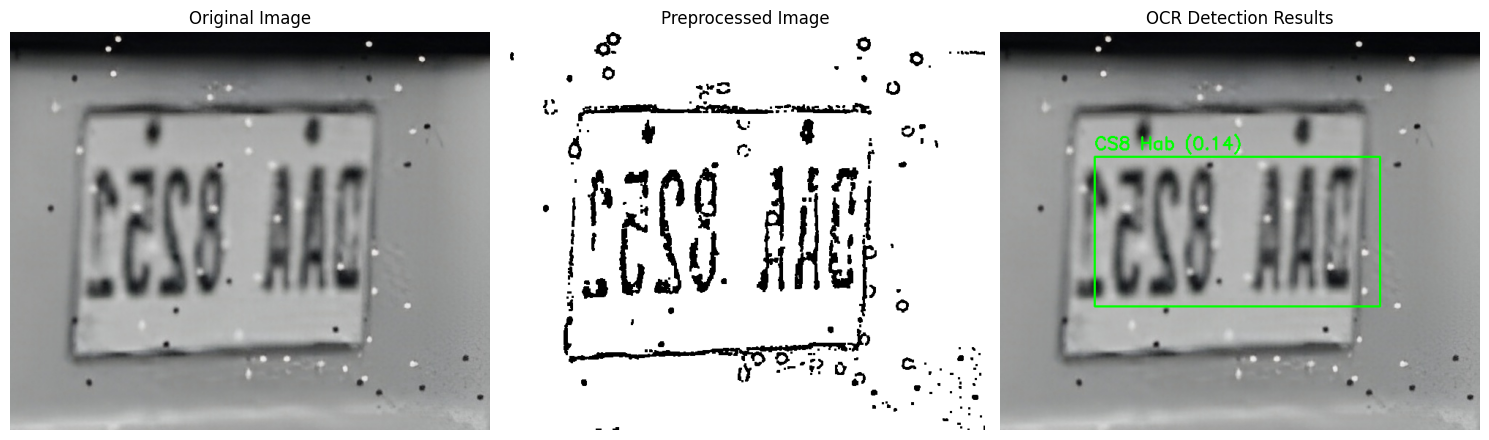

Final result: 


In [87]:
test_image_path = os.path.join('..', '..', '..', 'data', 'h_blur', 'train', 'enhanced', '124.jpg')
result = test_single_image(test_image_path)
print(f"Final result: {result}")